In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

import seaborn as sns

In [3]:
df = pd.read_csv("letter-recognition.data", header=None)

# Assign column names
columns = ["letter"] + [f"feature_{i}" for i in range(1, 17)]
df.columns = columns

print(df.head())

  letter  feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0      T          2          8          3          5          1          8   
1      I          5         12          3          7          2         10   
2      D          4         11          6          8          6         10   
3      N          7         11          6          6          3          5   
4      G          2          1          3          1          1          8   

   feature_7  feature_8  feature_9  feature_10  feature_11  feature_12  \
0         13          0          6           6          10           8   
1          5          5          4          13           3           9   
2          6          2          6          10           3           7   
3          9          4          6           4           4          10   
4          6          6          6           6           5           9   

   feature_13  feature_14  feature_15  feature_16  
0           0           8         

In [5]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['letter'])

# One-hot encoding
y = to_categorical(y)

# Features
X = df.drop("letter", axis=1)

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(16,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(26, activation='softmax')   # 26 classes
])


C:\Users\sai\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           2,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 26)                  │             858 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,370 (52.23 KB)

 Trainable params: 13,370 (52.23 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)


Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5571 - loss: 1.5749 - val_accuracy: 0.7466 - val_loss: 0.8963
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7923 - loss: 0.7067 - val_accuracy: 0.8184 - val_loss: 0.6300
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8402 - loss: 0.5377 - val_accuracy: 0.8266 - val_loss: 0.5494
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8702 - loss: 0.4406 - val_accuracy: 0.8709 - val_loss: 0.4315
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8910 - loss: 0.3691 - val_accuracy: 0.8813 - val_loss: 0.3676
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9020 - loss: 0.3215 - val_accuracy: 0.9003 - val_loss: 0.3420
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9133 - loss: 0.2825 - val_accuracy: 0.9162 - val_loss: 0.3032
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9223 - loss: 0.2547 - val_accuracy: 0.

In [13]:
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9345 - loss: 0.1984

Test Loss: 0.19837714731693268
Test Accuracy: 0.934499979019165


In [19]:
y_pred = model.predict(X_test)

# Convert from one-hot → label index
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nSample Predictions:")
for i in range(20):
    print("Actual:", label_encoder.inverse_transform([y_true[i]])[0],
          "Predicted:", label_encoder.inverse_transform([y_pred_classes[i]])[0])

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Sample Predictions:
Actual: T Predicted: Z
Actual: L Predicted: L
Actual: A Predicted: A
Actual: E Predicted: E
Actual: Q Predicted: Q
Actual: E Predicted: E
Actual: O Predicted: O
Actual: Q Predicted: Q
Actual: G Predicted: G
Actual: O Predicted: O
Actual: B Predicted: B
Actual: P Predicted: P
Actual: V Predicted: V
Actual: Q Predicted: Q
Actual: M Predicted: M
Actual: V Predicted: V
Actual: B Predicted: B
Actual: K Predicted: K
Actual: S Predicted: S
Actual: D Predicted: D


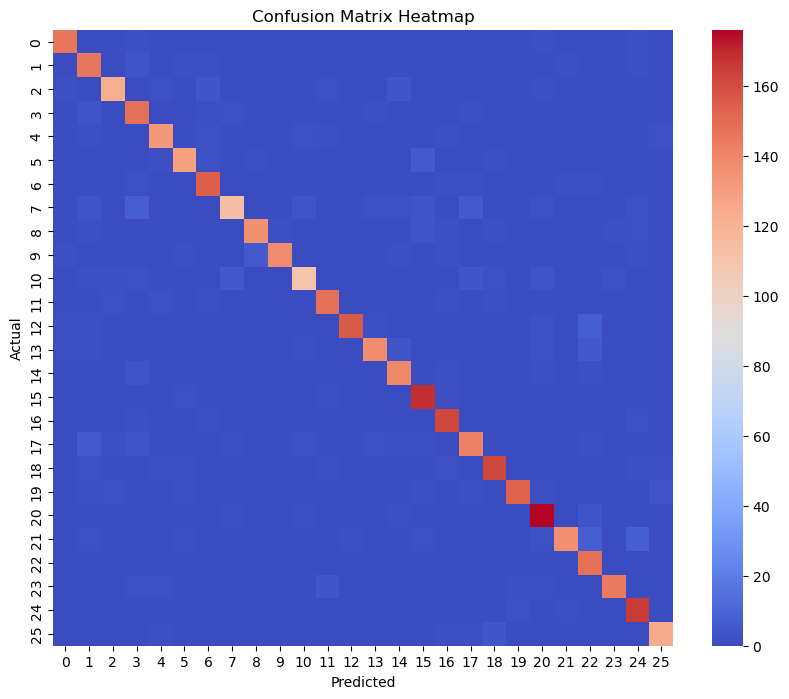

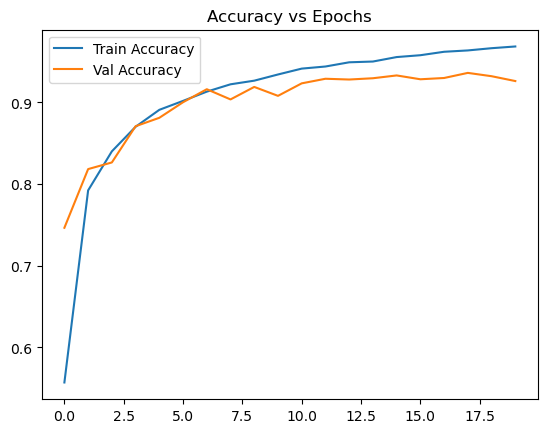

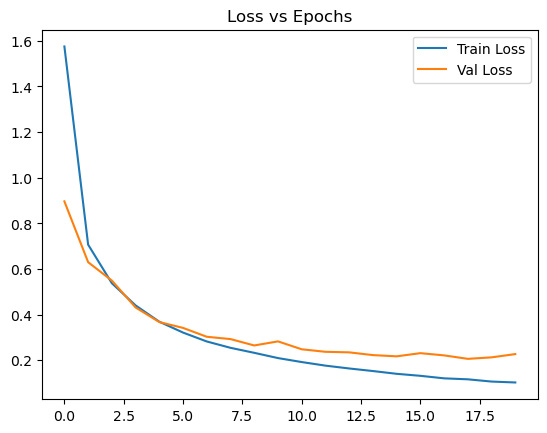

In [21]:

# =========================================
# 9. Confusion Matrix
# =========================================
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="coolwarm")
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================================
# 10. Accuracy Graph
# =========================================
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy vs Epochs")
plt.show()

# =========================================
# 11. Loss Graph
# =========================================
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss vs Epochs")
plt.show()